# OpenMeteo Weather Data Analysis - Extended Dataset (2023-2025)

Analysis of weather data from OpenMeteo for the period June 2023 to June 2025.

**Version**: V3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
data_path = '/Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_openmeteo_processed_20230601_to_20250630.csv'
print(f"Loading OpenMeteo data from: {data_path}")

df = pd.read_csv(data_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Loading OpenMeteo data from: /Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_openmeteo_processed_20230601_to_20250630.csv
Dataset shape: 6,615,120 rows × 41 columns
Date range: 2023-06-01 00:00:00+00:00 to 2025-06-30 23:00:00+00:00
Memory usage: 3160.6 MB


## 1. Dataset Overview

In [3]:
print("Dataset Info:")
print("="*60)
print(f"Total records: {len(df):,}")
print(f"Unique hexagons (res8): {df['h3_index_res8'].nunique():,}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nColumns ({len(df.columns)}):")
for col in df.columns:
    print(f"  - {col}: {df[col].dtype}")

Dataset Info:
Total records: 6,615,120
Unique hexagons (res8): 536
Date range: 2023-06-01 00:00:00+00:00 to 2025-06-30 23:00:00+00:00

Columns (41):
  - timestamp: datetime64[ns, UTC]
  - h3_index_res8: object
  - cloud_cover_pct_mean: float64
  - cloud_cover_pct_std: float64
  - cloud_cover_pct_min: float64
  - cloud_cover_pct_max: float64
  - cloud_cover_pct_count: int64
  - dew_point_c_mean: float64
  - dew_point_c_std: float64
  - dew_point_c_min: float64
  - dew_point_c_max: float64
  - dew_point_c_count: int64
  - humidity_pct_mean: float64
  - humidity_pct_std: float64
  - humidity_pct_min: float64
  - humidity_pct_max: float64
  - humidity_pct_count: int64
  - precipitation_mm_mean: float64
  - precipitation_mm_std: float64
  - precipitation_mm_min: float64
  - precipitation_mm_max: float64
  - precipitation_mm_count: int64
  - pressure_hpa_mean: float64
  - pressure_hpa_std: float64
  - pressure_hpa_min: float64
  - pressure_hpa_max: float64
  - pressure_hpa_count: int64
  - s

In [4]:
print("First 10 rows:")
display(df.head(10))

print("\nLast 10 rows:")
display(df.tail(10))

First 10 rows:


,timestamp,h3_index_res8,cloud_cover_pct_mean,cloud_cover_pct_std,cloud_cover_pct_min,cloud_cover_pct_max,cloud_cover_pct_count,dew_point_c_mean,dew_point_c_std,dew_point_c_min,dew_point_c_max,dew_point_c_count,humidity_pct_mean,humidity_pct_std,humidity_pct_min,humidity_pct_max,humidity_pct_count,precipitation_mm_mean,precipitation_mm_std,precipitation_mm_min,precipitation_mm_max,precipitation_mm_count,pressure_hpa_mean,pressure_hpa_std,pressure_hpa_min,pressure_hpa_max,pressure_hpa_count,solar_radiation_wm2_mean,solar_radiation_wm2_std,solar_radiation_wm2_min,solar_radiation_wm2_max,solar_radiation_wm2_count,temperature_c_mean,temperature_c_std,temperature_c_min,temperature_c_max,temperature_c_count,h3_lat_res8,h3_lon_res8,data_source,country
0,2023-06-01 00:00:00+00:00,8814927535fffff,100.00,NaN,100.00,100.00,1,10.50,NaN,10.50,10.50,1,76.00,NaN,76.00,76.00,1,0.00,NaN,0.00,0.00,1,975.40,NaN,975.40,975.40,1,0.00,NaN,0.00,0.00,1,14.70,NaN,14.70,14.70,1,45.00,128.00,openmeteo,JP
1,2023-06-01 00:00:00+00:00,881492d9d1fffff,100.00,NaN,100.00,100.00,1,12.40,NaN,12.40,12.40,1,85.00,NaN,85.00,85.00,1,0.90,NaN,0.90,0.90,1,982.80,NaN,982.80,982.80,1,0.00,NaN,0.00,0.00,1,15.00,NaN,15.00,15.00,1,45.00,127.00,openmeteo,JP
2,2023-06-01 00:00:00+00:00,882e004a31fffff,0.00,NaN,0.00,0.00,1,12.10,NaN,12.10,12.10,1,83.00,NaN,83.00,83.00,1,0.00,NaN,0.00,0.00,1,1012.50,NaN,1012.50,1012.50,1,0.00,NaN,0.00,0.00,1,15.00,NaN,15.00,15.00,1,40.00,144.00,openmeteo,JP
3,2023-06-01 00:00:00+00:00,882e009201fffff,96.00,NaN,96.00,96.00,1,12.80,NaN,12.80,12.80,1,67.00,NaN,67.00,67.00,1,0.00,NaN,0.00,0.00,1,1012.80,NaN,1012.80,1012.80,1,0.00,NaN,0.00,0.00,1,19.00,NaN,19.00,19.00,1,39.00,144.00,openmeteo,JP
4,2023-06-01 00:00:00+00:00,882e01ae65fffff,56.00,NaN,56.00,56.00,1,10.80,NaN,10.80,10.80,1,80.00,NaN,80.00,80.00,1,0.00,NaN,0.00,0.00,1,1013.40,NaN,1013.40,1013.40,1,0.00,NaN,0.00,0.00,1,14.10,NaN,14.10,14.10,1,39.00,142.00,openmeteo,JP
5,2023-06-01 00:00:00+00:00,882e027859fffff,0.00,NaN,0.00,0.00,1,10.40,NaN,10.40,10.40,1,75.00,NaN,75.00,75.00,1,0.00,NaN,0.00,0.00,1,1011.40,NaN,1011.40,1011.40,1,0.00,NaN,0.00,0.00,1,14.80,NaN,14.80,14.80,1,41.00,144.00,openmeteo,JP
6,2023-06-01 00:00:00+00:00,882e039893fffff,0.00,NaN,0.00,0.00,1,10.80,NaN,10.80,10.80,1,80.00,NaN,80.00,80.00,1,0.00,NaN,0.00,0.00,1,1012.70,NaN,1012.70,1012.70,1,0.00,NaN,0.00,0.00,1,14.10,NaN,14.10,14.10,1,40.00,143.00,openmeteo,JP
7,2023-06-01 00:00:00+00:00,882e045025fffff,74.00,NaN,74.00,74.00,1,9.90,NaN,9.90,9.90,1,54.00,NaN,54.00,54.00,1,0.00,NaN,0.00,0.00,1,1012.90,NaN,1012.90,1012.90,1,0.00,NaN,0.00,0.00,1,19.60,NaN,19.60,19.60,1,39.00,145.00,openmeteo,JP
8,2023-06-01 00:00:00+00:00,882e056f27fffff,96.00,NaN,96.00,96.00,1,11.80,NaN,11.80,11.80,1,73.00,NaN,73.00,73.00,1,0.00,NaN,0.00,0.00,1,1013.10,NaN,1013.10,1013.10,1,0.00,NaN,0.00,0.00,1,16.50,NaN,16.50,16.50,1,39.00,143.00,openmeteo,JP
9,2023-06-01 00:00:00+00:00,882e05b705fffff,80.00,NaN,80.00,80.00,1,10.60,NaN,10.60,10.60,1,54.00,NaN,54.00,54.00,1,0.00,NaN,0.00,0.00,1,1013.30,NaN,1013.30,1013.30,1,0.00,NaN,0.00,0.00,1,20.40,NaN,20.40,20.40,1,38.00,143.00,openmeteo,JP



Last 10 rows:


,timestamp,h3_index_res8,cloud_cover_pct_mean,cloud_cover_pct_std,cloud_cover_pct_min,cloud_cover_pct_max,cloud_cover_pct_count,dew_point_c_mean,dew_point_c_std,dew_point_c_min,dew_point_c_max,dew_point_c_count,humidity_pct_mean,humidity_pct_std,humidity_pct_min,humidity_pct_max,humidity_pct_count,precipitation_mm_mean,precipitation_mm_std,precipitation_mm_min,precipitation_mm_max,precipitation_mm_count,pressure_hpa_mean,pressure_hpa_std,pressure_hpa_min,pressure_hpa_max,pressure_hpa_count,solar_radiation_wm2_mean,solar_radiation_wm2_std,solar_radiation_wm2_min,solar_radiation_wm2_max,solar_radiation_wm2_count,temperature_c_mean,temperature_c_std,temperature_c_min,temperature_c_max,temperature_c_count,h3_lat_res8,h3_lon_res8,data_source,country
6615110,2025-06-30 23:00:00+00:00,884ecdd9b7fffff,100.00,NaN,100.00,100.00,1,21.00,NaN,21.00,21.00,1,63.00,NaN,63.00,63.00,1,0.00,NaN,0.00,0.00,1,1012.20,NaN,1012.20,1012.20,1,0.00,NaN,0.00,0.00,1,28.80,NaN,28.80,28.80,1,26.00,144.00,openmeteo,JP
6615111,2025-06-30 23:00:00+00:00,884ece10bbfffff,94.00,NaN,94.00,94.00,1,23.40,NaN,23.40,23.40,1,79.00,NaN,79.00,79.00,1,0.20,NaN,0.20,0.20,1,1012.80,NaN,1012.80,1012.80,1,0.00,NaN,0.00,0.00,1,27.30,NaN,27.30,27.30,1,27.00,145.00,openmeteo,JP
6615112,2025-06-30 23:00:00+00:00,884ed92725fffff,98.00,NaN,98.00,98.00,1,22.80,NaN,22.80,22.80,1,80.00,NaN,80.00,80.00,1,0.00,NaN,0.00,0.00,1,1013.40,NaN,1013.40,1013.40,1,0.00,NaN,0.00,0.00,1,26.50,NaN,26.50,26.50,1,29.00,144.00,openmeteo,JP
6615113,2025-06-30 23:00:00+00:00,884ed9caadfffff,49.00,NaN,49.00,49.00,1,21.80,NaN,21.80,21.80,1,74.00,NaN,74.00,74.00,1,0.00,NaN,0.00,0.00,1,1013.40,NaN,1013.40,1013.40,1,0.00,NaN,0.00,0.00,1,26.80,NaN,26.80,26.80,1,29.00,145.00,openmeteo,JP
6615114,2025-06-30 23:00:00+00:00,884edb18c5fffff,21.00,NaN,21.00,21.00,1,20.10,NaN,20.10,20.10,1,69.00,NaN,69.00,69.00,1,0.00,NaN,0.00,0.00,1,1014.20,NaN,1014.20,1014.20,1,0.00,NaN,0.00,0.00,1,26.20,NaN,26.20,26.20,1,30.00,145.00,openmeteo,JP
6615115,2025-06-30 23:00:00+00:00,884edd3211fffff,49.00,NaN,49.00,49.00,1,23.00,NaN,23.00,23.00,1,85.00,NaN,85.00,85.00,1,0.10,NaN,0.10,0.10,1,1013.00,NaN,1013.00,1013.00,1,0.00,NaN,0.00,0.00,1,25.70,NaN,25.70,25.70,1,28.00,145.00,openmeteo,JP
6615116,2025-06-30 23:00:00+00:00,884ee880b7fffff,100.00,NaN,100.00,100.00,1,23.90,NaN,23.90,23.90,1,76.00,NaN,76.00,76.00,1,0.10,NaN,0.10,0.10,1,1011.40,NaN,1011.40,1011.40,1,0.00,NaN,0.00,0.00,1,28.50,NaN,28.50,28.50,1,24.00,145.00,openmeteo,JP
6615117,2025-06-30 23:00:00+00:00,884ee9895dfffff,99.00,NaN,99.00,99.00,1,23.00,NaN,23.00,23.00,1,68.00,NaN,68.00,68.00,1,0.00,NaN,0.00,0.00,1,1011.20,NaN,1011.20,1011.20,1,0.00,NaN,0.00,0.00,1,29.50,NaN,29.50,29.50,1,24.00,144.00,openmeteo,JP
6615118,2025-06-30 23:00:00+00:00,884eeaa08bfffff,100.00,NaN,100.00,100.00,1,23.10,NaN,23.10,23.10,1,72.00,NaN,72.00,72.00,1,0.00,NaN,0.00,0.00,1,1011.90,NaN,1011.90,1011.90,1,0.00,NaN,0.00,0.00,1,28.60,NaN,28.60,28.60,1,25.00,145.00,openmeteo,JP
6615119,2025-06-30 23:00:00+00:00,884eebab0bfffff,100.00,NaN,100.00,100.00,1,23.60,NaN,23.60,23.60,1,74.00,NaN,74.00,74.00,1,0.00,NaN,0.00,0.00,1,1011.60,NaN,1011.60,1011.60,1,0.00,NaN,0.00,0.00,1,28.70,NaN,28.70,28.70,1,25.00,144.00,openmeteo,JP


## 2. Temporal Coverage Analysis

In [5]:
df['date'] = df['timestamp'].dt.date
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month

all_dates = pd.date_range('2023-06-01', '2025-06-30', freq='D').date
existing_dates = set(df['date'].unique())
missing_dates = sorted(set(all_dates) - existing_dates)

print(f"Temporal Coverage Analysis:")
print("="*60)
print(f"Expected days: {len(all_dates)}")
print(f"Days with data: {len(existing_dates)}")
print(f"Missing days: {len(missing_dates)}")
print(f"Coverage: {len(existing_dates)/len(all_dates)*100:.1f}%")

if len(existing_dates) == len(all_dates):
    print("\n✓ COMPLETE COVERAGE CONFIRMED!")
else:
    print(f"\n⚠ Missing {len(missing_dates)} days")

print("\nYearly coverage:")
yearly_counts = df.groupby('year').size()
for year in [2023, 2024, 2025]:
    count = yearly_counts.get(year, 0)
    print(f"  {year}: {count:,} records")

print("\nMonthly coverage by year:")
monthly_counts = df.groupby([df['timestamp'].dt.year, df['timestamp'].dt.month]).size()
for year in [2023, 2024, 2025]:
    print(f"\n{year}:")
    for month in range(1, 13):
        if year == 2023 and month < 6:
            continue
        if year == 2025 and month > 6:
            break
        count = monthly_counts.get((year, month), 0)
        month_name = pd.Timestamp(f'{year}-{month:02d}-01').strftime('%B')
        print(f"  {month_name:10s}: {count:8,} records")

Temporal Coverage Analysis:
Expected days: 761
Days with data: 698
Missing days: 63
Coverage: 91.7%

⚠ Missing 63 days

Yearly coverage:
  2023: 2,537,376 records
  2024: 2,247,504 records
  2025: 1,830,240 records

Monthly coverage by year:

2023:
  June      :  385,920 records
  July      :  398,784 records
  August    :  345,960 records
  September :  330,480 records
  October   :  310,248 records
  November  :  367,200 records
  December  :  398,784 records

2024:
  January   :    1,488 records
  February  :  373,056 records
  March     :        0 records
  April     :   31,680 records
  May       :  374,232 records
  June      :  184,320 records
  July      :  184,512 records
  August    :  246,960 records
  September :  116,640 records
  October   :  119,040 records
  November  :  370,800 records
  December  :  244,776 records

2025:
  January   :        0 records
  February  :  360,192 records
  March     :  398,784 records
  April     :  335,520 records
  May       :  398,784 r

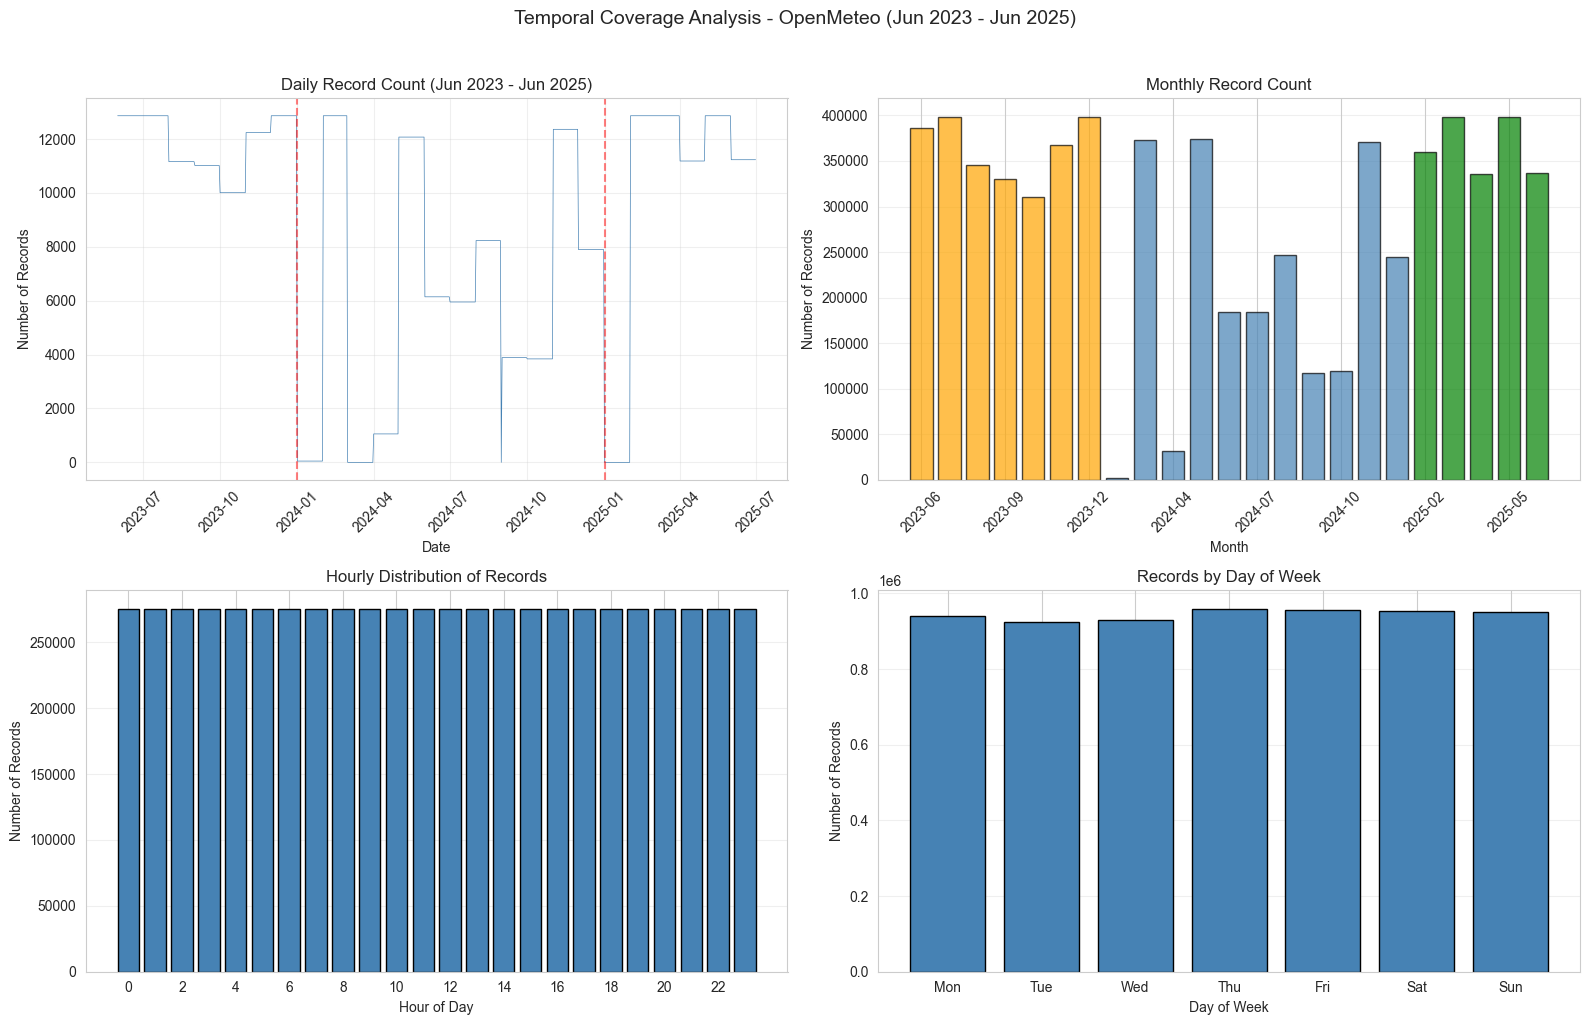

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

daily_counts = df.groupby('date').size().reindex(all_dates, fill_value=0)
axes[0, 0].plot(daily_counts.index, daily_counts.values, linewidth=0.5, color='steelblue')
axes[0, 0].set_title('Daily Record Count (Jun 2023 - Jun 2025)', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Number of Records')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

for year in [2024, 2025]:
    year_start = pd.Timestamp(f'{year}-01-01')
    axes[0, 0].axvline(x=year_start, color='red', linestyle='--', alpha=0.5)

monthly_counts_plot = df.groupby(df['timestamp'].dt.to_period('M')).size()
axes[0, 1].bar(range(len(monthly_counts_plot)), monthly_counts_plot.values,
               color=['orange' if '2023' in str(idx) else 'steelblue' if '2024' in str(idx) else 'green'
                      for idx in monthly_counts_plot.index],
               edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Monthly Record Count', fontsize=12)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of Records')
axes[0, 1].set_xticks(range(0, len(monthly_counts_plot), 3))
axes[0, 1].set_xticklabels([str(idx) for idx in monthly_counts_plot.index][::3], rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

hourly_counts = df.groupby(df['timestamp'].dt.hour).size()
axes[1, 0].bar(hourly_counts.index, hourly_counts.values, color='steelblue', edgecolor='black')
axes[1, 0].set_title('Hourly Distribution of Records', fontsize=12)
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Number of Records')
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].grid(True, alpha=0.3, axis='y')

weekday_counts = df.groupby(df['timestamp'].dt.dayofweek).size()
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 1].bar(range(7), weekday_counts.reindex(range(7), fill_value=0).values,
               color='steelblue', edgecolor='black')
axes[1, 1].set_title('Records by Day of Week', fontsize=12)
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Number of Records')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(weekday_names)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Temporal Coverage Analysis - OpenMeteo (Jun 2023 - Jun 2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Missing Data Analysis

In [7]:
numerical_features = [
    'cloud_cover_pct_mean', 'dew_point_c_mean', 'humidity_pct_mean',
    'precipitation_mm_mean', 'pressure_hpa_mean', 'solar_radiation_wm2_mean',
    'temperature_c_mean'
]

available_features = [f for f in numerical_features if f in df.columns]

missing_stats = pd.DataFrame({
    'Missing Count': df[available_features].isnull().sum(),
    'Missing %': (df[available_features].isnull().sum() / len(df) * 100).round(2),
    'Available Count': df[available_features].notnull().sum(),
    'Available %': (df[available_features].notnull().sum() / len(df) * 100).round(2)
})

print("Missing Data Summary:")
print("="*60)
display(missing_stats)

Missing Data Summary:


,Missing Count,Missing %,Available Count,Available %
cloud_cover_pct_mean,8064,0.12,6607056,99.88
dew_point_c_mean,9528,0.14,6605592,99.86
humidity_pct_mean,5856,0.09,6609264,99.91
precipitation_mm_mean,8040,0.12,6607080,99.88
pressure_hpa_mean,8040,0.12,6607080,99.88
solar_radiation_wm2_mean,8808,0.13,6606312,99.87
temperature_c_mean,5880,0.09,6609240,99.91


## 4. Feature Distributions

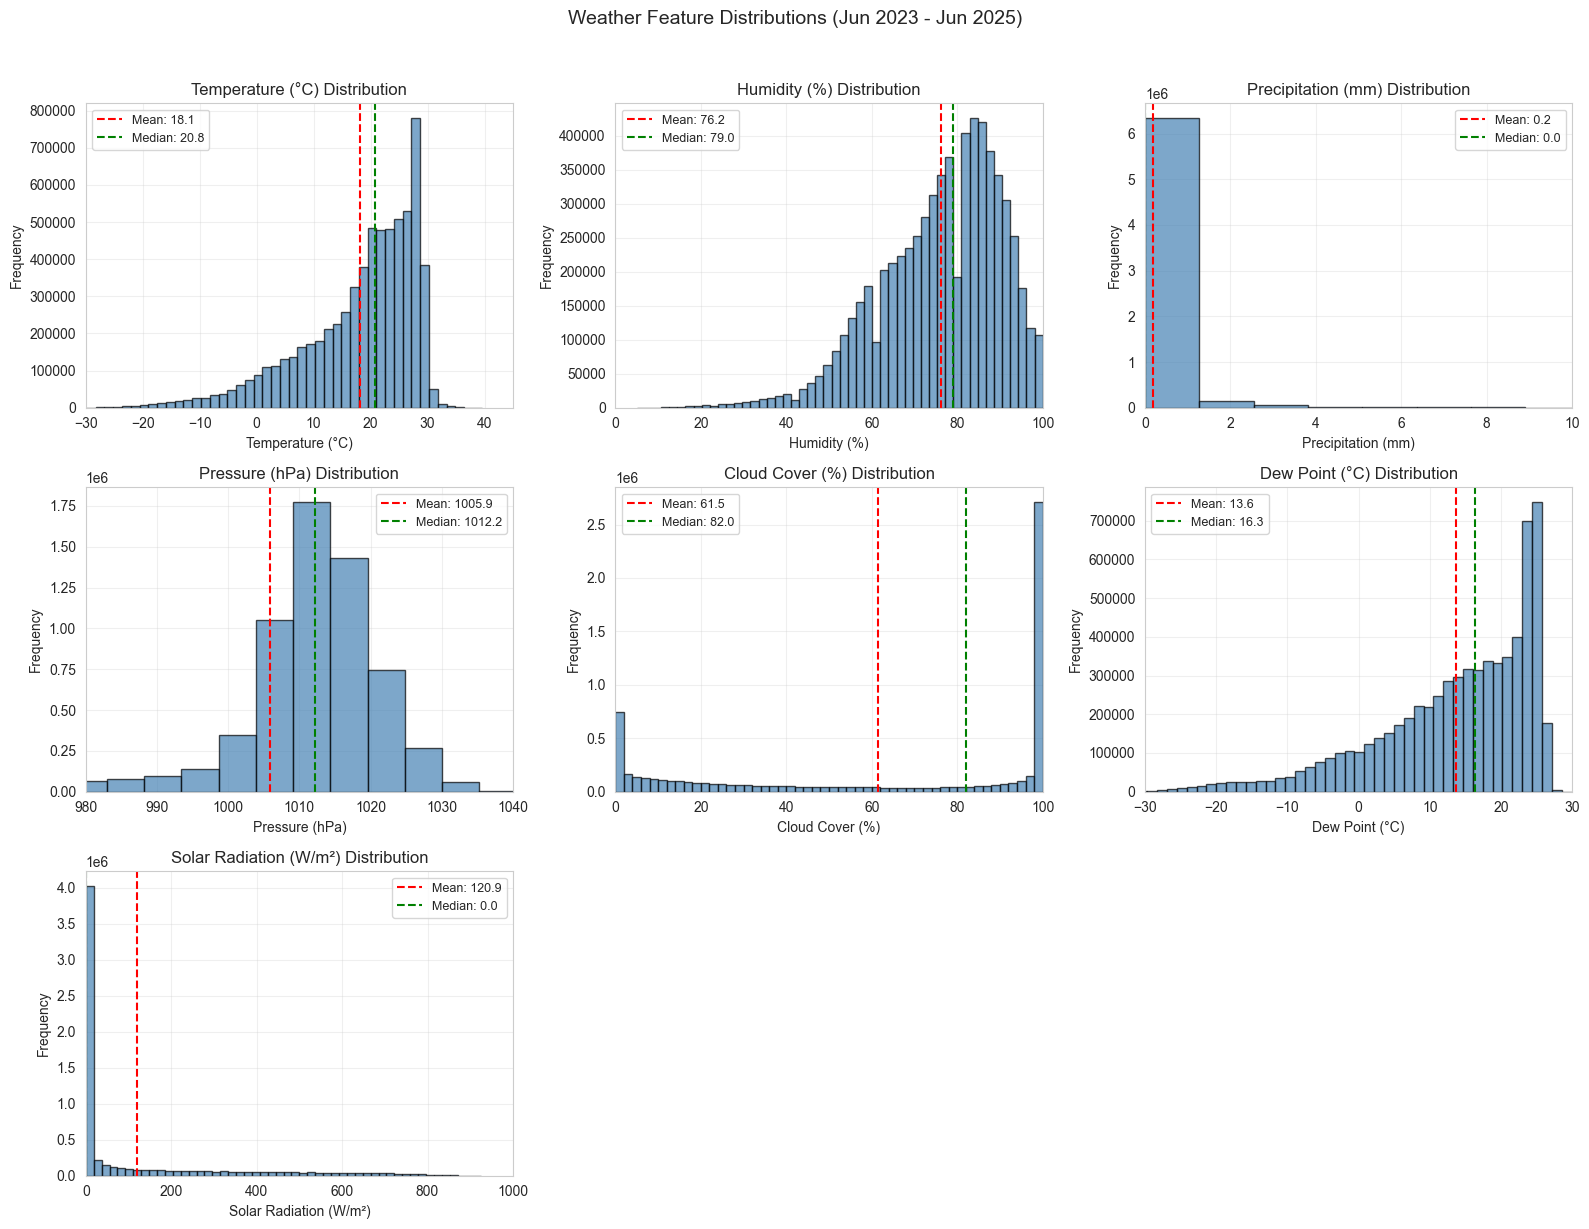

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

features_to_plot = [
    ('temperature_c_mean', 'Temperature (°C)', (-30, 45)),
    ('humidity_pct_mean', 'Humidity (%)', (0, 100)),
    ('precipitation_mm_mean', 'Precipitation (mm)', (0, 10)),
    ('pressure_hpa_mean', 'Pressure (hPa)', (980, 1040)),
    ('cloud_cover_pct_mean', 'Cloud Cover (%)', (0, 100)),
    ('dew_point_c_mean', 'Dew Point (°C)', (-30, 30)),
    ('solar_radiation_wm2_mean', 'Solar Radiation (W/m²)', (0, 1000)),
]

for idx, (feature, label, xlim) in enumerate(features_to_plot):
    if feature in df.columns:
        data = df[feature].dropna()
        data = data[np.isfinite(data)]
        
        if len(data) > 0:
            axes[idx].hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
            axes[idx].set_xlabel(label)
            axes[idx].set_ylabel('Frequency')
            axes[idx].set_title(f'{label} Distribution')
            if xlim:
                axes[idx].set_xlim(xlim)
            
            mean_val = data.mean()
            median_val = data.median()
            axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
            axes[idx].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.1f}')
            axes[idx].legend(loc='best', fontsize=9)
            axes[idx].grid(True, alpha=0.3)

for idx in range(len(features_to_plot), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Weather Feature Distributions (Jun 2023 - Jun 2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Geographic Coverage

In [9]:
hex_locations = df[['h3_index_res8', 'h3_lat_res8', 'h3_lon_res8']].drop_duplicates()
print(f"Geographic Coverage:")
print("="*60)
print(f"Unique hexagons: {len(hex_locations):,}")
print(f"Latitude range: {hex_locations['h3_lat_res8'].min():.2f} to {hex_locations['h3_lat_res8'].max():.2f}")
print(f"Longitude range: {hex_locations['h3_lon_res8'].min():.2f} to {hex_locations['h3_lon_res8'].max():.2f}")

hex_data_counts = df.groupby('h3_index_res8').agg({
    'timestamp': ['count', 'min', 'max']
}).reset_index()
hex_data_counts.columns = ['h3_index_res8', 'record_count', 'first_date', 'last_date']
hex_with_counts = hex_locations.merge(hex_data_counts, on='h3_index_res8')

print(f"\nRecords per hexagon:")
print(f"  Mean: {hex_with_counts['record_count'].mean():.0f}")
print(f"  Median: {hex_with_counts['record_count'].median():.0f}")
print(f"  Min: {hex_with_counts['record_count'].min()}")
print(f"  Max: {hex_with_counts['record_count'].max()}")

expected_records = len(all_dates) * 24
completeness = hex_with_counts['record_count'] / expected_records * 100
print(f"\nData completeness per hexagon:")
print(f"  Mean: {completeness.mean():.1f}%")
print(f"  Median: {completeness.median():.1f}%")

Geographic Coverage:
Unique hexagons: 536
Latitude range: 24.00 to 45.00
Longitude range: 123.00 to 145.00

Records per hexagon:
  Mean: 12342
  Median: 12360
  Min: 7248
  Max: 16032

Data completeness per hexagon:
  Mean: 67.6%
  Median: 67.7%


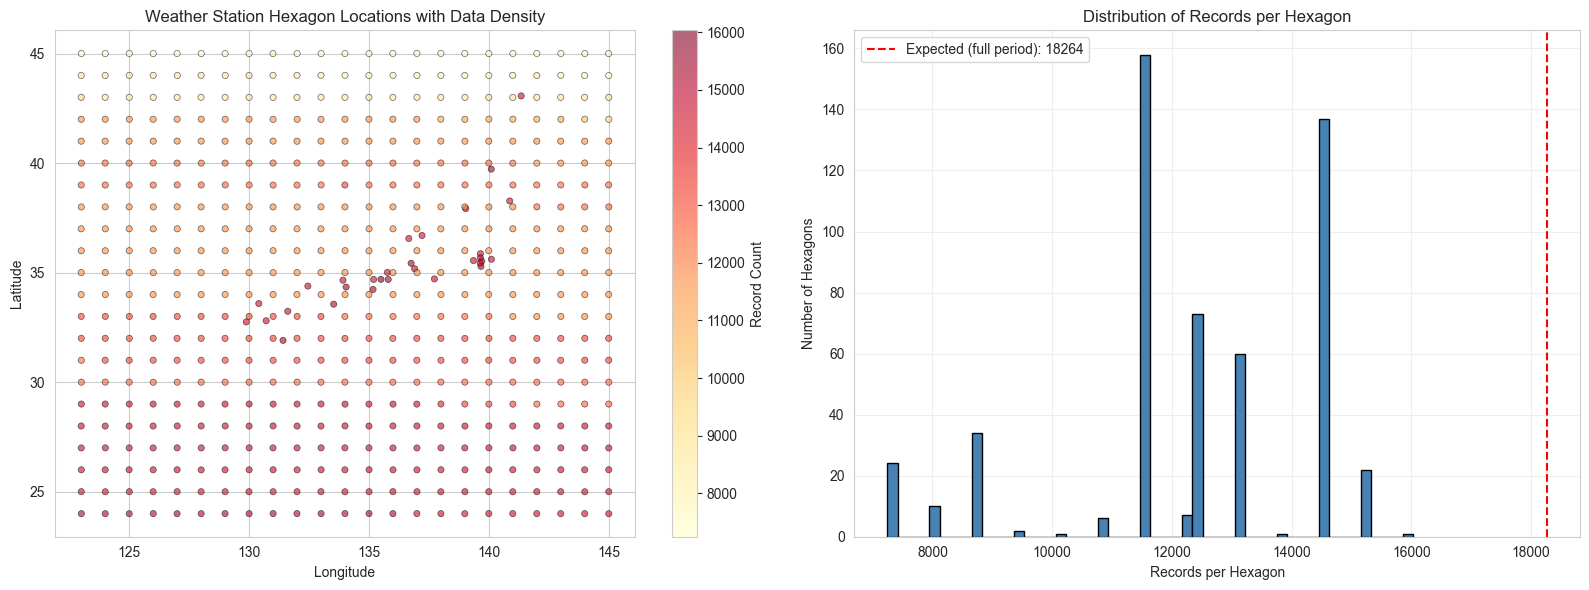

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter = axes[0].scatter(hex_with_counts['h3_lon_res8'],
                         hex_with_counts['h3_lat_res8'],
                         c=hex_with_counts['record_count'],
                         cmap='YlOrRd', s=20, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Weather Station Hexagon Locations with Data Density')
plt.colorbar(scatter, ax=axes[0], label='Record Count')

axes[1].hist(hex_with_counts['record_count'], bins=50, edgecolor='black', color='steelblue')
axes[1].set_xlabel('Records per Hexagon')
axes[1].set_ylabel('Number of Hexagons')
axes[1].set_title('Distribution of Records per Hexagon')
axes[1].axvline(expected_records, color='red', linestyle='--',
                label=f'Expected (full period): {expected_records}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Seasonal and Temporal Patterns

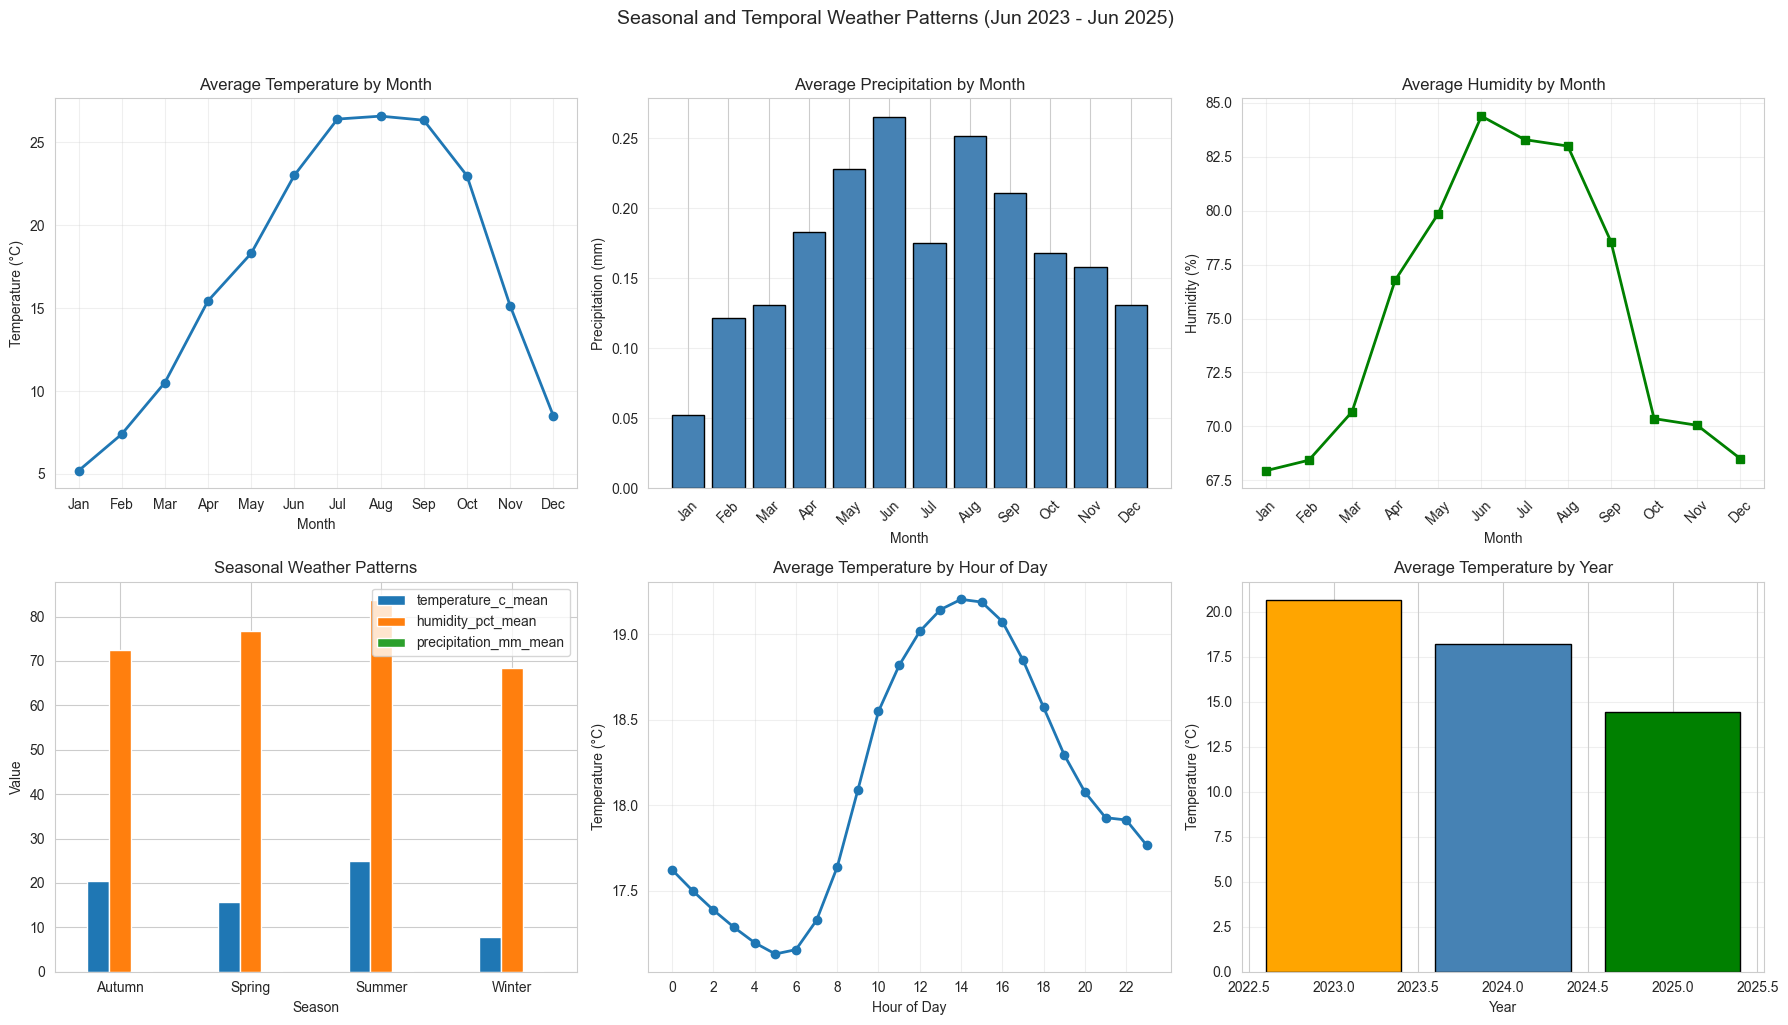

In [11]:
df['hour'] = df['timestamp'].dt.hour
df['season'] = df['month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                 3: 'Spring', 4: 'Spring', 5: 'Spring',
                                 6: 'Summer', 7: 'Summer', 8: 'Summer',
                                 9: 'Autumn', 10: 'Autumn', 11: 'Autumn'})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

monthly_temp = df.groupby('month')['temperature_c_mean'].mean()
axes[0, 0].plot(monthly_temp.index, monthly_temp.values, marker='o', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Temperature (°C)')
axes[0, 0].set_title('Average Temperature by Month')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0, 0].grid(True, alpha=0.3)

monthly_precip = df.groupby('month')['precipitation_mm_mean'].mean()
axes[0, 1].bar(monthly_precip.index, monthly_precip.values, color='steelblue', edgecolor='black')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Precipitation (mm)')
axes[0, 1].set_title('Average Precipitation by Month')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

monthly_humidity = df.groupby('month')['humidity_pct_mean'].mean()
axes[0, 2].plot(monthly_humidity.index, monthly_humidity.values, marker='s', linewidth=2, color='green', markersize=6)
axes[0, 2].set_xlabel('Month')
axes[0, 2].set_ylabel('Humidity (%)')
axes[0, 2].set_title('Average Humidity by Month')
axes[0, 2].set_xticks(range(1, 13))
axes[0, 2].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
axes[0, 2].grid(True, alpha=0.3)

if 'season' in df.columns and df['season'].notna().any():
    seasonal_stats = df.groupby('season')[['temperature_c_mean', 'humidity_pct_mean',
                                           'precipitation_mm_mean']].mean()
    seasonal_stats.plot(kind='bar', ax=axes[1, 0])
    axes[1, 0].set_title('Seasonal Weather Patterns', fontsize=12)
    axes[1, 0].set_xlabel('Season')
    axes[1, 0].set_ylabel('Value')
    axes[1, 0].legend(loc='best')
    axes[1, 0].tick_params(axis='x', rotation=0)

hourly_temp = df.groupby('hour')['temperature_c_mean'].mean()
axes[1, 1].plot(hourly_temp.index, hourly_temp.values, marker='o', linewidth=2)
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Temperature (°C)')
axes[1, 1].set_title('Average Temperature by Hour of Day')
axes[1, 1].set_xticks(range(0, 24, 2))
axes[1, 1].grid(True, alpha=0.3)

yearly_temp = df.groupby('year')['temperature_c_mean'].mean()
axes[1, 2].bar(yearly_temp.index, yearly_temp.values, color=['orange', 'steelblue', 'green'], edgecolor='black')
axes[1, 2].set_xlabel('Year')
axes[1, 2].set_ylabel('Temperature (°C)')
axes[1, 2].set_title('Average Temperature by Year')
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Seasonal and Temporal Weather Patterns (Jun 2023 - Jun 2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Yearly Comparison

In [12]:
yearly_stats = df.groupby('year')[available_features].agg(['mean', 'std', 'min', 'max'])

print("Yearly Weather Statistics Comparison:")
print("="*60)
for feature in available_features:
    print(f"\n{feature.replace('_', ' ').title()}:")
    display(yearly_stats[feature].round(2))

Yearly Weather Statistics Comparison:

Cloud Cover Pct Mean:


,mean,std,min,max
year,,,,
2023,60.51,40.54,0.00,100.00
2024,61.08,40.64,0.00,100.00
2025,63.55,41.39,0.00,100.00



Dew Point C Mean:


,mean,std,min,max
year,,,,
2023,16.27,9.84,-39.40,29.90
2024,13.70,11.66,-36.00,29.80
2025,9.89,10.47,-37.90,29.00



Humidity Pct Mean:


...

,mean,std,min,max
year,,,,
2023,1005.24,25.39,787.90,1040.20
2024,1007.07,24.56,785.10,1040.50
2025,1005.32,26.84,778.90,1038.20



Solar Radiation Wm2 Mean:


,mean,std,min,max
year,,,,
2023,122.05,206.23,0.00,907.00
2024,117.21,205.15,0.00,926.00
2025,123.75,210.34,0.00,924.00



Temperature C Mean:


,mean,std,min,max
year,,,,
2023,20.65,9.17,-37.50,39.50
2024,18.22,10.82,-33.30,38.90
2025,14.46,9.31,-35.20,37.50


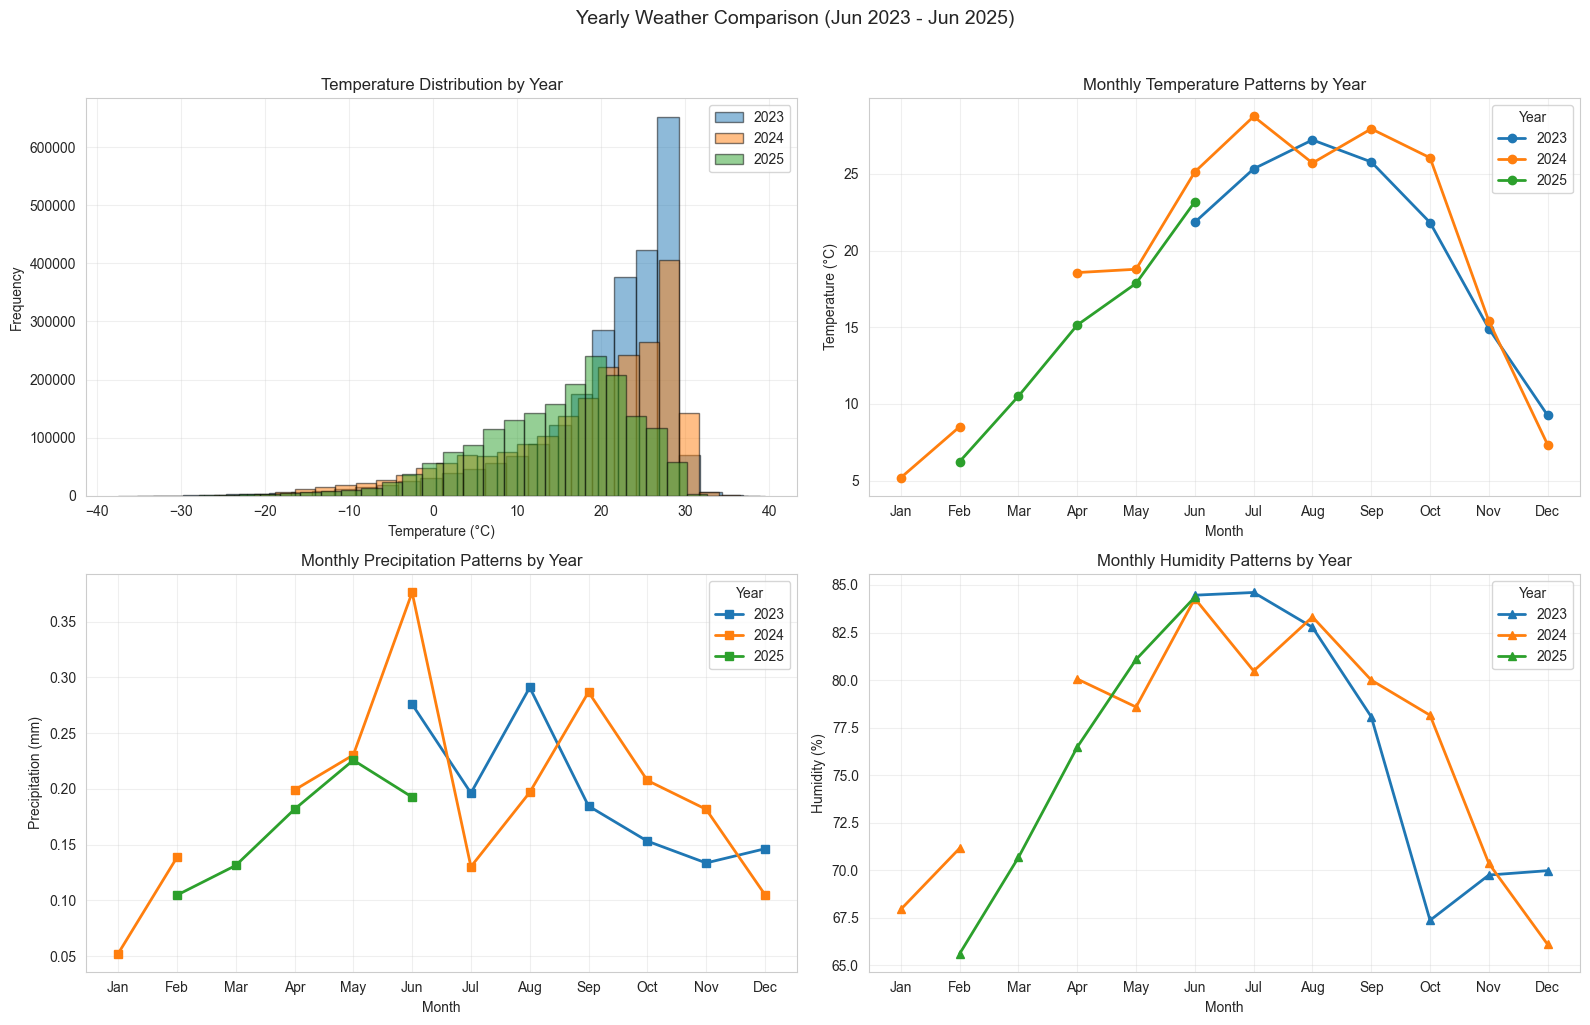

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for year in [2023, 2024, 2025]:
    year_data = df[df['year'] == year]['temperature_c_mean'].dropna()
    if len(year_data) > 0:
        axes[0, 0].hist(year_data, bins=30, alpha=0.5, label=str(year), edgecolor='black')

axes[0, 0].set_xlabel('Temperature (°C)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Temperature Distribution by Year')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

yearly_monthly_temp = df.groupby(['year', 'month'])['temperature_c_mean'].mean().unstack(level=0)
yearly_monthly_temp.plot(ax=axes[0, 1], marker='o', linewidth=2)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Temperature (°C)')
axes[0, 1].set_title('Monthly Temperature Patterns by Year')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0, 1].legend(title='Year')
axes[0, 1].grid(True, alpha=0.3)

yearly_monthly_precip = df.groupby(['year', 'month'])['precipitation_mm_mean'].mean().unstack(level=0)
yearly_monthly_precip.plot(ax=axes[1, 0], marker='s', linewidth=2)
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Precipitation (mm)')
axes[1, 0].set_title('Monthly Precipitation Patterns by Year')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1, 0].legend(title='Year')
axes[1, 0].grid(True, alpha=0.3)

yearly_monthly_humidity = df.groupby(['year', 'month'])['humidity_pct_mean'].mean().unstack(level=0)
yearly_monthly_humidity.plot(ax=axes[1, 1], marker='^', linewidth=2)
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Humidity (%)')
axes[1, 1].set_title('Monthly Humidity Patterns by Year')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1, 1].legend(title='Year')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Yearly Weather Comparison (Jun 2023 - Jun 2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Feature Correlations

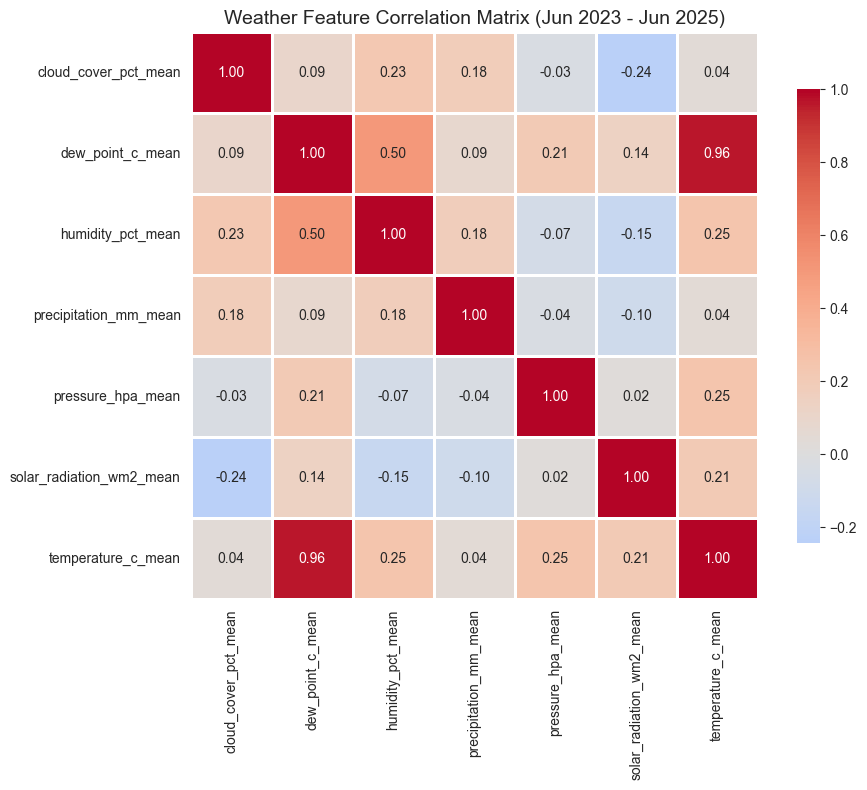


Strongest correlations with temperature:
  dew_point_c_mean: 0.962


In [14]:
correlation_matrix = df[available_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Weather Feature Correlation Matrix (Jun 2023 - Jun 2025)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nStrongest correlations with temperature:")
if 'temperature_c_mean' in correlation_matrix.columns:
    temp_corr = correlation_matrix['temperature_c_mean'].sort_values(ascending=False)
    for feature, corr in temp_corr.items():
        if feature != 'temperature_c_mean' and abs(corr) > 0.3:
            print(f"  {feature}: {corr:.3f}")

## 9. Statistical Summary

In [15]:
print("Statistical Summary of Weather Features (Full Dataset):")
print("="*60)
display(df[available_features].describe())

Statistical Summary of Weather Features (Full Dataset):


,cloud_cover_pct_mean,dew_point_c_mean,humidity_pct_mean,precipitation_mm_mean,pressure_hpa_mean,solar_radiation_wm2_mean,temperature_c_mean
count,6607056.00,6605592.00,6609264.00,6607080.00,6607080.00,6606312.00,6609240.00
mean,61.54,13.63,76.17,0.19,1005.88,120.88,18.11
std,40.83,10.97,14.01,0.86,25.54,207.03,10.11
min,0.00,-39.40,5.00,0.00,778.90,0.00,-37.50
25%,16.00,7.70,67.00,0.00,1006.30,0.00,12.90
50%,82.00,16.30,79.00,0.00,1012.20,0.00,20.80
75%,100.00,22.90,87.00,0.00,1017.00,164.00,26.00
max,100.00,29.90,100.00,63.60,1040.50,926.00,39.50


In [16]:
print("OPENMETEO EXTENDED DATASET SUMMARY (Jun 2023 - Jun 2025)")
print("="*60)

print("\n📊 DATASET OVERVIEW:")
print(f"   Total records: {len(df):,}")
print(f"   Time period: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"   Unique locations (hexagons): {df['h3_index_res8'].nunique()}")
print(f"   Temporal resolution: Hourly")

print("\n📅 TEMPORAL COVERAGE:")
print(f"   Days with data: {len(existing_dates)}/{len(all_dates)} ({len(existing_dates)/len(all_dates)*100:.1f}%)")
print(f"   Data period: {(df['timestamp'].max() - df['timestamp'].min()).days} days")
if len(existing_dates) == len(all_dates):
    print("   ✓ COMPLETE COVERAGE FOR ANALYSIS PERIOD")

print("\n🌡️ KEY WEATHER STATISTICS:")
if 'temperature_c_mean' in df.columns:
    print(f"   Temperature range: {df['temperature_c_mean'].min():.1f}°C to {df['temperature_c_mean'].max():.1f}°C")
    print(f"   Mean temperature: {df['temperature_c_mean'].mean():.1f}°C")
if 'humidity_pct_mean' in df.columns:
    print(f"   Mean humidity: {df['humidity_pct_mean'].mean():.1f}%")
if 'precipitation_mm_mean' in df.columns:
    print(f"   Mean precipitation: {df['precipitation_mm_mean'].mean():.2f} mm")
if 'pressure_hpa_mean' in df.columns:
    print(f"   Mean pressure: {df['pressure_hpa_mean'].mean():.1f} hPa")

print("\n✅ DATA COMPLETENESS:")
for feature in available_features:
    completeness = df[feature].notna().mean() * 100
    print(f"   {feature}: {completeness:.1f}%")

print("\n💾 DATASET READY FOR:")
print("   • PM2.5 enrichment with weather features")
print("   • Multi-year weather analysis")
print("   • Spatial-temporal modeling")
print("   • Air quality prediction models")
print("   • Climate trend analysis")

OPENMETEO EXTENDED DATASET SUMMARY (Jun 2023 - Jun 2025)

📊 DATASET OVERVIEW:
   Total records: 6,615,120
   Time period: 2023-06-01 to 2025-06-30
   Unique locations (hexagons): 536
   Temporal resolution: Hourly

📅 TEMPORAL COVERAGE:
   Days with data: 698/761 (91.7%)
   Data period: 760 days

🌡️ KEY WEATHER STATISTICS:
   Temperature range: -37.5°C to 39.5°C
   Mean temperature: 18.1°C
   Mean humidity: 76.2%
   Mean precipitation: 0.19 mm
   Mean pressure: 1005.9 hPa

✅ DATA COMPLETENESS:
   cloud_cover_pct_mean: 99.9%
   dew_point_c_mean: 99.9%
   humidity_pct_mean: 99.9%
   precipitation_mm_mean: 99.9%
   pressure_hpa_mean: 99.9%
   solar_radiation_wm2_mean: 99.9%
   temperature_c_mean: 99.9%

💾 DATASET READY FOR:
   • PM2.5 enrichment with weather features
   • Multi-year weather analysis
   • Spatial-temporal modeling
   • Air quality prediction models
   • Climate trend analysis
